In [1]:
import cv2
import matplotlib.pyplot as plt
import cvzone
import os
import random

In [5]:
images_path = "Apple_Datasets/train/images"
labels_path = "Apple_Datasets/train/labels"

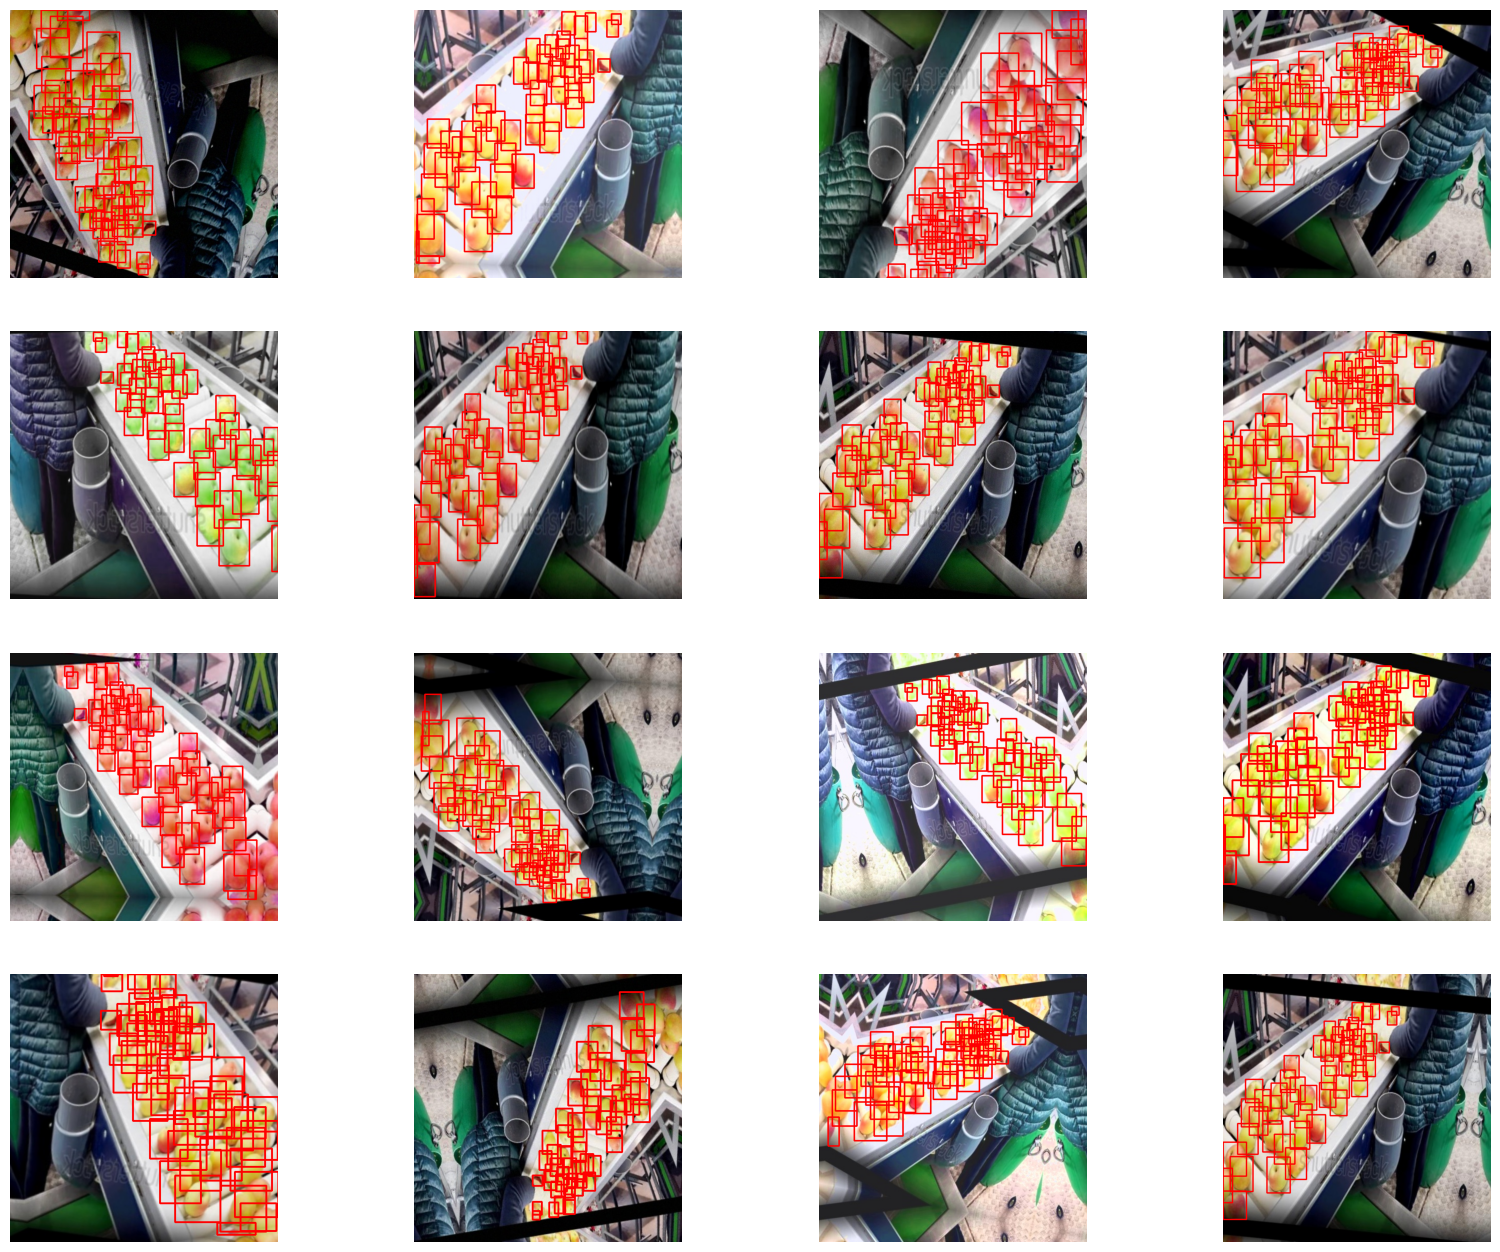

In [7]:
fig, ax = plt.subplots(4,4,figsize=(20,16))
ax = ax.ravel()

for i in range(16):
    img_files = os.listdir(images_path)
    img_file_name = random.choice(img_files) 

    img_path = os.path.join(images_path,img_file_name)
    label_path = os.path.join(labels_path,f"{img_file_name[:-4]}.txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    height, width, _ = img.shape

    with open(label_path,'r') as f:
        for line in f:
            data = line.strip().split()

            cls_id = int(data[0])

            # --- CORRECT YOLO FORMAT CONVERSION ---
            x_center = float(data[1]) * width
            y_center = float(data[2]) * height
            w_bbox = float(data[3]) * width
            h_bbox = float(data[4]) * height

            x1 = int(x_center - w_bbox / 2)
            y1 = int(y_center - h_bbox / 2)
            x2 = int(x_center + w_bbox / 2)
            y2 = int(y_center + h_bbox / 2)
            # -------------------------------------

            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

    ax[i].imshow(img)
    ax[i].axis("off")

plt.show()
